<a href="https://colab.research.google.com/github/sheicksen/CISC483-EngageTactics/blob/JiaQi-RNN-Implementation/Truthseeker_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Attempted RNN Implementation

- RNN useful when the order of sentence matter
- RNN has use in sentiment classification (words that go with certain emotions), want to extend this to fake news
- Want to be able to predict real/fake news, associating certain words with fake news

In [2]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

In [3]:
uploaded = files.upload()

# Assuming you upload a file named 'your_file_name.csv'
# You will need to replace 'your_file_name.csv' with the actual name of your uploaded file.

Saving Truth_Seeker_Model_Dataset.csv to Truth_Seeker_Model_Dataset.csv


In [36]:
# Get the name of the uploaded file(s)
# This assumes only one file is uploaded. If multiple, you'll need to choose the correct one.
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  truthseeker_df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first few rows of the DataFrame, shape and headers
#display(truthseeker_df.head())
print(truthseeker_df.shape)

# print(truthseeker_df['tweet'][0])
print(truthseeker_df.info()) # print df info

User uploaded file "Truth_Seeker_Model_Dataset.csv"
(134198, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134198 entries, 0 to 134197
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               134198 non-null  int64  
 1   author                   134198 non-null  object 
 2   statement                134198 non-null  object 
 3   target                   134198 non-null  bool   
 4   BinaryNumTarget          134198 non-null  float64
 5   manual_keywords          134198 non-null  object 
 6   tweet                    134198 non-null  object 
 7   5_label_majority_answer  134198 non-null  object 
 8   3_label_majority_answer  134198 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 8.3+ MB
None


In [52]:
# View the distribution of answers in the '3_label_majority_answer' column
display(truthseeker_df['3_label_majority_answer'].value_counts())

,count
3_label_majority_answer,
Agree,128471
Disagree,5727


In [31]:
# Define target (y) and features (X)

# Combine 'tweet' and 'statement' columns to provide more context
# A separator like '[SEP]' can be useful to distinguish between the two parts
# X = truthseeker_df['tweet'] + " [SEP] " + truthseeker_df['statement']

# Version with no separator
X = truthseeker_df['tweet']

# Define the new target 'y' by XORing '3_label_majority_answer' (converted to binary) with 'BinaryNumTarget'
# We'll assume 'Agree' from '3_label_majority_answer' means 0 and disagree means 1
y_3_label_binary = (truthseeker_df['3_label_majority_answer'] != 'Agree').astype(int)

# Perform the XOR operation. Ensure both are integers for bitwise XOR.
# Here
y = (y_3_label_binary ^ truthseeker_df['BinaryNumTarget'].astype(int))

# at 0.01, with high epoch, saw clear overfitting
sample_fraction = 0.5 # Adjust this value to change the sample size

# Sample the data before splitting
X_sample, y_sample = X.sample(frac=sample_fraction, random_state=42), y.sample(frac=sample_fraction, random_state=42)

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (53679,)
X_test shape: (13420,)
y_train shape: (53679,)
y_test shape: (13420,)


In [49]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re # Import regular expression module

# Function to remove mentions
def remove_mentions(text):
    return re.sub(r'@\S+', '', text)

# Apply the function to X to clean mentions before fitting the tokenizer
X_cleaned = X.apply(remove_mentions)
print("Cleaned entry:", X_cleaned[1])

# Parameters for tokenization and padding
VOCAB_SIZE = 15000  # Max number of words to keep, based on word frequency
MAX_SEQUENCE_LENGTH = 150 # Max length of each tweet sequence

# Initialize tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

# Fit tokenizer on the cleaned combined text
tokenizer.fit_on_texts(X_cleaned)

# Apply mention removal to X_train and X_test before converting to sequences
X_train_cleaned = X_train.apply(remove_mentions)
X_test_cleaned = X_test.apply(remove_mentions)

# Convert text to sequences of numbers using the fitted tokenizer
training_sequences = tokenizer.texts_to_sequences(X_train_cleaned)
testing_sequences = tokenizer.texts_to_sequences(X_test_cleaned)

# Pad sequences to ensure uniform length
padded_training_sequences = pad_sequences(training_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
padded_testing_sequences = pad_sequences(testing_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Shape of padded training sequences: {padded_training_sequences.shape}")
print(f"Shape of padded testing sequences: {padded_testing_sequences.shape}")
# each number is an ID for that word, assigned by tokenizer
print(f"Example of a padded sequence:\n{padded_training_sequences[1]}")
print(f"Vocabulary size: {len(tokenizer.word_index)}")

Cleaned entry:    Not as many people are literally starving and out in the streets as they were in the 19th century. Isnt capitalism grand?

Meanwhile, were facing an eviction moratorium threatening to make millions of Americans homeless.

Fuck off with this corporatist propaganda.
Shape of padded training sequences: (53679, 150)
Shape of padded testing sequences: (13420, 150)
Example of a padded sequence:
[   2  699 1739  827  730  637   26 2620 2017  410 2189   38  306    7
    6  275  185 3102 4748  338    4   19  325 5322  820  827  173    2
  536    7  631  512 3904    5  938 3459   17 2070  472    3    2  115
    8   21    1    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0  

In [45]:
# Calculate the length of each tweet
tweet_lengths = truthseeker_df['tweet'].apply(len)

# Print some stats on length
print(f"Mean tweet length: {tweet_lengths.mean():.2f}")
print(f"Max tweet length: {tweet_lengths.max()}")
print(f"Median tweet length: {tweet_lengths.median()}")
print(f"Min tweet length: {tweet_lengths.min()}")

Mean tweet length: 217.31
Max tweet length: 993
Median tweet length: 231.0
Min tweet length: 6


This `tokenizer.json` file can later be loaded to reconstruct the exact same tokenizer, which is crucial for using the trained model with new, unseen text data consistently.

The `padded_sequences` now contain the numerical representation of your tweets, ready to be fed into an embedding layer. Each number corresponds to a word in the tokenizer's vocabulary. The next step would typically involve creating a Keras Embedding layer as part of an RNN model.

In [ ]:
import json

# Save the tokenizer configuration to a JSON file
tokenizer_json = tokenizer.to_json()
with open('tokenizer.json', 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print("Tokenizer saved to tokenizer.json")

Tokenizer saved to tokenizer.json


### Incorporating Pre-trained Word Embeddings (GloVe)

To improve the model's performance, especially with limited data, we can use pre-trained word embeddings. These embeddings capture semantic relationships between words based on large text corpora. We will use GloVe embeddings as an example.

In [46]:
# Download GloVe embeddings (using a smaller version for speed)
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

# Load the GloVe word embeddings into a dictionary
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

--2026-05-07 19:56:50--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-07 19:56:50--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-07 19:56:50--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

Now, we'll create an embedding matrix that we can use to initialize our Keras Embedding layer. This matrix will contain the GloVe vectors for the words present in our tokenizer's vocabulary.

In [50]:
# Create an embedding matrix
EMBEDDING_DIM = 100 # GloVe 6B.100d has 100-dimensional vectors

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

print(f'Shape of embedding matrix: {embedding_matrix.shape}')
print(embedding_matrix)

Shape of embedding matrix: (15000, 100)
[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.038194   -0.24487001  0.72812003 ... -0.1459      0.82779998
   0.27061999]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.083593   -0.42291    -0.49880999 ...  0.33612001 -0.36706001
  -0.31119001]
 [-1.03390002 -0.32738     0.35025999 ... -1.3937      0.31834
  -0.66709   ]]


Now, we will modify the RNN model to use this pre-trained embedding matrix. We'll set `trainable=True` to allow for fine-tuning the embeddings on our specific dataset.

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Define the RNN model with pre-trained embeddings
model_pretrained_embedding = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, weights=[embedding_matrix], trainable=True),
    SimpleRNN(units=64, return_sequences=True),
    SimpleRNN(units=64),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_pretrained_embedding.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model_pretrained_embedding.summary()

# Define EarlyStopping callback
# It monitors 'val_loss' and stops if it doesn't improve for 3 consecutive epochs.
# 'restore_best_weights' ensures the model keeps the weights from the epoch with the best validation loss.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Retrain the model with early stopping
# Reusing the early_stopping callback defined previously
history_pretrained = model_pretrained_embedding.fit(
    padded_training_sequences,
    y_train,
    epochs=10, # Start with a reasonable number of epochs
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

print("Model training with pre-trained embeddings complete.")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 1,500,000 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 154s 111ms/step - accuracy: 0.4958 - loss: 0.7015 - val_accuracy: 0.5063 - val_loss: 0.6950
Epoch 2/10
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 204s 113ms/step - accuracy: 0.5048 - loss: 0.6980 - val_accuracy: 0.4997 - val_loss: 0.6958
Epoch 3/10
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 154s 115ms/step - accuracy: 0.5039 - loss: 0.6977 - val_accuracy: 0.4951 - val_loss: 0.6962
Epoch 4/10
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 141s 105ms/step - accuracy: 0.5049 - loss: 0.6960 - val_accuracy: 0.5161 - val_loss: 0.6926
Epoch 5/10
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 151s 113ms/step - accuracy: 0.5041 - loss: 0.6941 - val_accuracy: 0.4837 - val_loss: 0.6940
Epoch 6/10
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 200s 111ms/step - accuracy: 0.5064 - loss: 0.6941 - val_accuracy: 0.5161 - val_loss: 0.6930
Epoch 7/10
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 149s 111ms/step - accuracy: 0.5079 - loss: 0.6936 - val_accuracy: 0.5163 - val_loss: 0.6946
Epoch 8/10
1342/1342 ━━━━━━━━━━━━━━━━━━━━ 144s 108ms/step - ac

Let's evaluate the performance of the model with pre-trained embeddings on the test set.

In [35]:
# Evaluate the model with pre-trained embeddings on the test data
loss_pretrained, accuracy_pretrained = model_pretrained_embedding.evaluate(padded_testing_sequences, y_test)

print(f"\nTest Loss (Pre-trained Embeddings): {loss_pretrained:.4f}")
print(f"Test Accuracy (Pre-trained Embeddings): {accuracy_pretrained:.4f}")

420/420 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.5152 - loss: 0.6927

Test Loss (Pre-trained Embeddings): 0.6927
Test Accuracy (Pre-trained Embeddings): 0.5152


### Version of model not using pretrained embeddings

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Define the RNN model
embedding_dim = 128 # The size of the vector space in which words will be embedded

# Embedding: Take the words (int form) and represents them as a vector of numbers.
           # Training adjusts those numbers, to reflect how the word was used in training
           # data. Words with similar meanings would be used in similar context, and so would
           # have similar embeddings.
# units=64 defines dimension of output, chosen as a good default value
model = Sequential([
    Embedding(VOCAB_SIZE, embedding_dim),
    SimpleRNN(units=64, return_sequences=True), # add another layer to possible capture more obscure patterns
    SimpleRNN(units=64),
    Dense(1, activation='sigmoid') # Binary classification output
])

# Compile the model, defines how it will train
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
# It monitors 'val_loss' and stops if it doesn't improve for 3 consecutive epochs.
# 'restore_best_weights' ensures the model keeps the weights from the epoch with the best validation loss.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    padded_training_sequences,
    y_train,
    epochs=20, # Start with a reasonable number of epochs, EarlyStopping will stop it if needed
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stopping]
)

print("Model training complete.")

Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.5000 - loss: 0.7149 - val_accuracy: 0.4884 - val_loss: 0.7136
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5128 - loss: 0.6923 - val_accuracy: 0.4698 - val_loss: 0.7773
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.7436 - loss: 0.5257 - val_accuracy: 0.4884 - val_loss: 0.8500
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.8811 - loss: 0.3062 - val_accuracy: 0.5256 - val_loss: 1.2167
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9394 - loss: 0.1688 - val_accuracy: 0.5442 - val_loss: 1.0457
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9848 - loss: 0.0439 - val_accuracy: 0.5302 - val_loss: 1.3447
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Model training complete.


In [26]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(padded_testing_sequences, y_test)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5019 - loss: 0.7088

Test Loss: 0.7088
Test Accuracy: 0.5019


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step


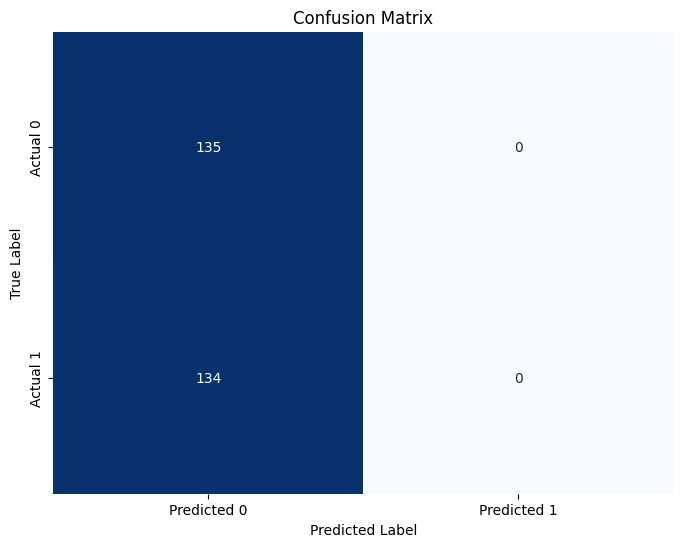

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions on the test data
y_pred_probs = model.predict(padded_testing_sequences)

# Convert probabilities to binary predictions (0 or 1)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix helps us understand the types of errors made by the model:

*   **True Negatives (Top-Left)**: Correctly predicted 0 (negative class).
*   **False Positives (Top-Right)**: Incorrectly predicted 1 (positive class) when the actual was 0.
*   **False Negatives (Bottom-Left)**: Incorrectly predicted 0 (negative class) when the actual was 1.
*   **True Positives (Bottom-Right)**: Correctly predicted 1 (positive class).

By examining these values, you can gain insight into the specific strengths and weaknesses of your model's classification performance.